Imports

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from Background_functions import read_audio_file, split_audio_segments, start_end_times
from STFT import resample_audio, stft_calculation, plot_spectrogram
from DFT import dp, dtw_calc

from pathlib import Path
from scipy.spatial import distance as dist

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\DataSubmission\2023_04_22")

Data download

In [ ]:
audio = DATA_22 / "20230422_171301.WAV"
f_s, x = read_audio_file(audio)
duration = len(x) / f_s  # Duration of the audio in seconds

start = 0.0  # Start time in seconds
window = 3.0  # Window length in seconds
start_t = []
end_t = []

while start < duration:
    end = min(start + window, duration)  # Ensure we don't exceed the audio duration
    start_t.append(start)
    end_t.append(end)
    start += window  # Move to the next window
length = len(start_t)
print(length)

audio_segments = split_audio_segments(x, f_s, start_t, end_t)

89479


Template

In [ ]:
text = DATA_22 / "20230422_171301.Detections.selections.txt"
temp_marks, start_t_temp, end_t_temp = start_end_times(text)

whale_call_segments = split_audio_segments(x, f_s, start_t_temp, end_t_temp)
print(len(whale_call_segments))
audio_template_1 = whale_call_segments[13]

628


STFT Model

In [ ]:
def short_time_calc(sig, fs):
    fs_new = 2000
    resampled_sig = resample_audio(sig, fs, fs_new)
    f_seg, t_seg, Zxx_seg = stft_calculation(resampled_sig, fs, fs_new)
    #plot_spectrogram(f_seg, t_seg, Zxx_seg, fs_new)
    return f_seg, t_seg, Zxx_seg, fs_new

Running loop for STFT template analysis

In [ ]:
stft_cost = []
oor = []
for i in range(628):
    audio_seg = whale_call_segments[i]
    f_temp, t_temp, Zxx_temp, fs_new = short_time_calc(audio_template_1, f_s)
    f_seg, t_seg, Zxx_seg, fs_new = short_time_calc(audio_seg, f_s)
    dtw_cost = dtw_calc(Zxx_temp, Zxx_seg)
    stft_cost.append(dtw_cost)
    if 0.0< dtw_cost < 0.3:
        oor.append(i)
    
    #print(i)
avg_cost = np.mean(stft_cost)
max_cost = np.max(stft_cost)
min_cost = np.min(stft_cost)
print(f"avg_cost: {avg_cost:.2f}")
print(f"max_cost: {max_cost:.2f}")
print(f"min_cost: {min_cost:.2f}")
print(oor)

avg_cost: 4.99
max_cost: 31.07
min_cost: 0.00
[13]


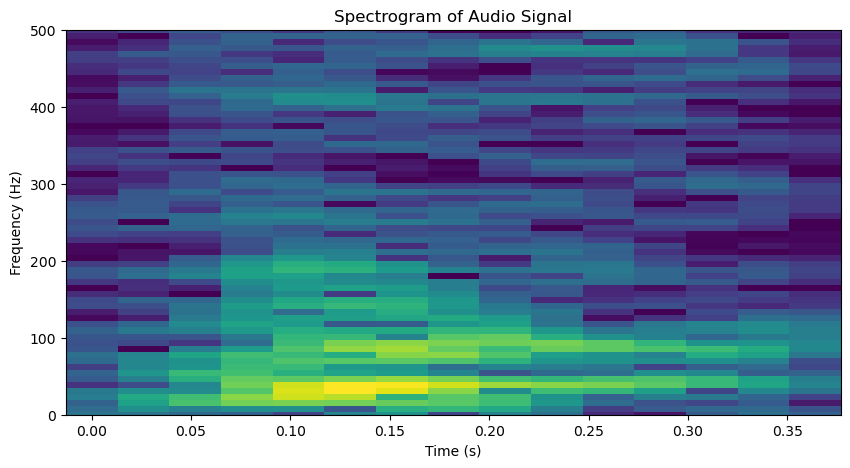

1


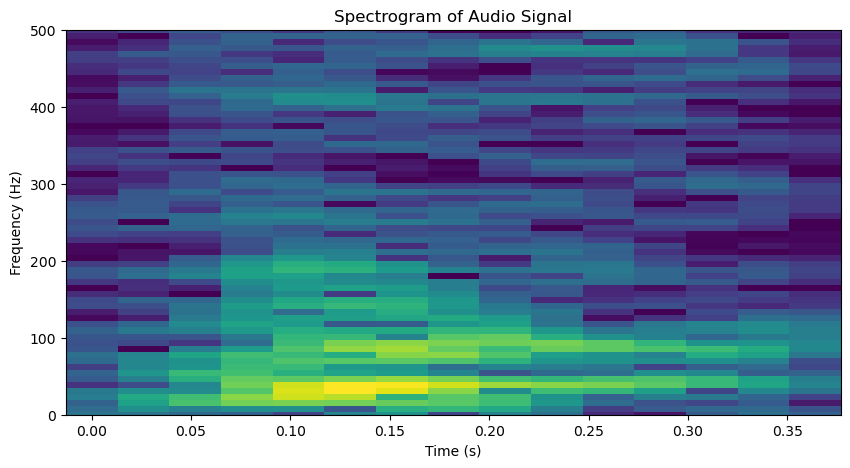

3.3306690738754696e-16
0
13
134740.8599375


In [ ]:
plot_spectrogram(f_temp, t_temp, Zxx_temp, fs_new)
print(len(oor))
for j in range(1):
    f_sig, t_sig, Zxx_sig, fs_new = short_time_calc(whale_call_segments[oor[j]], f_s)
    plot_spectrogram(f_sig, t_sig, Zxx_sig, fs_new)
    plt.show()
    dtw_cost = dtw_calc(Zxx_temp, Zxx_sig)
    print(dtw_cost)
    print(j)
    print(oor[j])
    print(start_t_temp[oor[j]])


Running loop for comparison

In [ ]:
stft_cost = []
for i in range(100):
    audio_seg = audio_segments[i]
    f_temp, t_temp, Zxx_temp, fs_new = short_time_calc(audio_template_1, f_s)
    f_seg, t_seg, Zxx_seg, fs_new = short_time_calc(audio_seg, f_s)
    stft_cost.append(dtw_calc(Zxx_temp, Zxx_seg))
    #print(i)
